## Цели практической работы

* Изучить и предобработать данные в задаче оттока.

* Научиться применять для решения задачи решающие деревья и оценивать результаты модели.

## Что входит в практическую работу

*  Загрузка и предобработка данных.
*  Применение и настройка линейных моделей.
*  Применение и настройка решающего дерева.
*  Сравнение моделей.
*  Оценка важности признаков.

## Что оценивается

Выполнены все задания ноутбука (заполнены пустые ячейки, даны ответы на вопросы).

## Что нужно сделать
Решите задачу классификации оттоковых клиентов телекома: для каждого клиента необходимо определить, перестанет он пользоваться услугами оператора в ближайшее время или нет.

In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

from plotnine import *
import plotnine

df = pd.read_csv("telecom_churn.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


Сделайте первичную обработку данных:

1. Выбросите колонку State.

2. Колонки International plan и Voice mail plan закодируйте следующим образом: Yes замените на 1, а No на 0.

3. Переведите целевую переменную (Churn) в числа: True в 1, а False в 0.

In [2]:
# ваш код здесь

In [3]:
df = df.drop('State', axis=1)

In [4]:
df['International plan'] = df['International plan'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Voice mail plan'] = df['Voice mail plan'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x else 0)

Выведите на экран первые строки изменённой таблицы, чтобы проверить, что все преобразования сработали.

In [5]:
# ваш код здесь

In [6]:
df.head(10)

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
5,118,510,1,0,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,0
6,121,510,0,1,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,0
7,147,415,1,0,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,0
8,117,408,0,0,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,0
9,141,415,1,1,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,0


Создайте матрицу объект-признак X и вектор с целевой переменной (Churn) y.

In [7]:
# ваш код здесь

In [8]:
y = df['Churn']
X = df.drop(['Churn'], axis=1)


Проверьте баланс классов. Является ли выборка сбалансированной?

In [9]:
# ваш код здесь

<Axes: >

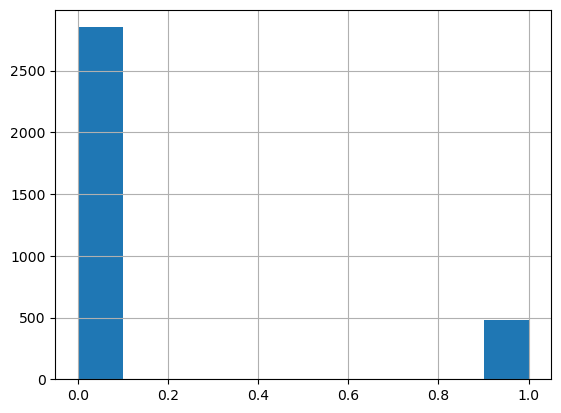

In [10]:
y.hist()

Разбейте данные на тренировочную и тестовую части, размер тестовой части — 30%.

In [11]:
from sklearn.model_selection import train_test_split

# ваш код здесь

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=63)

Для линейных моделей очень важно масштабирование признаков. Поэтому отмасштабируйте признаки при помощи [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), обучив метод на тренировочных данных и применив его и к трейну, и к тесту.

In [13]:
from sklearn.preprocessing import StandardScaler

# ваш код здесь

In [14]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

После масштабирования признаков X_train и X_test перестали быть объектами типа pd.DataFrame, это неудобно. Приведите их снова к pd.DataFrame.

In [15]:
# ваш код здесь

Обучите на тренировочных данных с параметрами по умолчанию:

1) логистическую регрессию;

2) метод опорных векторов (с kernel='linear').

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ваш код здесь

In [17]:
model_logreg = LogisticRegression()
model_SVC = SVC(kernel='linear', probability=True)

model_logreg.fit(X_train, y_train)
model_SVC.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

С помощью обученных моделей сделайте предсказание на тестовых данных. Вычислите значение метрики roc-auc на тесте. 

Не забудьте, что для корректного вычисления roc-auc необходимо предсказывать не сами классы, а их вероятности (чтобы SVC мог это сделать, при объявлении модели поставьте probability=True).

In [18]:
from sklearn.metrics import roc_auc_score

y_prob_lr = model_logreg.predict_proba(X_test)[:, 1]
y_prob_svc = model_SVC.predict_proba(X_test)[:, 1]
# ваш код здесь

In [19]:
roc_logreg = roc_auc_score(y_test, y_prob_lr)
roc_svc = roc_auc_score(y_test, y_prob_svc)
print(f'ROC_AUC для LogisticRegression {roc_logreg}')
print(f'ROC_AUC для SVC {roc_svc}')

ROC_AUC для LogisticRegression 0.82176417352471
ROC_AUC для SVC 0.6385973221913036


Теперь обучите решающее дерево с параметрами по умолчанию на тренировочных данных, сделайте предсказание на тесте и вычислите на тесте roc-auc.

In [20]:
from sklearn.tree import DecisionTreeClassifier

# ваш код здесь

In [21]:
model_STDDecisionTree = DecisionTreeClassifier(random_state=42)

model_STDDecisionTree.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [22]:
y_prob_DR = model_STDDecisionTree.predict_proba(X_test)[:, 1]


In [23]:
roc_DR = roc_auc_score(y_test, y_prob_DR)
print(f'ROC_AUC для DecisionTree {roc_DR}')


ROC_AUC для DecisionTree 0.815429117574917


Нужно ли масшабировать признаки для обучения решающего дерева? Проверьте это, заново разбив данные на тренировочную и тестовую части (назовите новые полученные объекты новыми названиями), и проведите обучение, предсказание и оценку метрики до масштабирования и после.

In [24]:
# ваш код здесь

In [25]:
XDR_train, XDR_test, yDR_train, yDR_test = train_test_split(X, y, test_size=0.3, random_state=63)

model_DecisionTree = DecisionTreeClassifier(random_state=42)
model_DecisionTree.fit(XDR_train, yDR_train)
y_prob_DR = model_DecisionTree.predict_proba(XDR_test)[:, 1]
roc_DR = roc_auc_score(yDR_test, y_prob_DR)
print(f'ROC_AUC для DecisionTree {roc_DR}')

ROC_AUC для DecisionTree 0.8148497432991348


Какой вывод про масштабирование признаков для обучения дерева можно сделать?

Теперь ваша цель — максимально улучшить модели. Для этого:

1) у линейных моделей подберите гиперпараметр С (переберите 20 значений C в диапазоне от 0.1 до 10 с равным шагом);

2) у решающего дерева подберите max_depth (переберите глубину от 1 до 10 с шагом 1) и criterion — gini или entropy (см. [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)).

Для подбора параметров используйте [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) с пятью фолдами и метрикой roc-auc или обычные циклы.

Подбор параметров осуществляется только по тренировочным данным!

После подбора гиперпараметров обучите модели с найденными гиперпараметрами на тренировочных данных, сделайте предсказания на тесте и оцените их качество (roc_auc).

In [26]:
from sklearn.model_selection import GridSearchCV

# ваш код здесь

In [27]:
# Задаем значения параметров, которые хотим перебрать
param_grid_logreg = {'C': np.arange(0.1, 10, 0.5), 'penalty': ['l1', 'l2'], 'class_weight':['balanced', None]}
param_grid_DT = {'max_depth': range(1,11), 'criterion':['gini', 'entropy'] }

# Создаем объекты GridSearchCV для каждой модели
grid_logreg = GridSearchCV(model_logreg, param_grid_logreg, cv=5, scoring='roc_auc', verbose=1)
grid_DT = GridSearchCV(model_DecisionTree, param_grid_DT, cv=5, scoring='roc_auc', verbose=1)

In [28]:
grid_logreg.fit(X_train, y_train)
print("Лучшие параметры для Logistic Regression:", grid_logreg.best_params_)
print("Лучший результат для Logistic Regression:", grid_logreg.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Лучшие параметры для Logistic Regression: {'C': 4.6, 'class_weight': 'balanced', 'penalty': 'l2'}
Лучший результат для Logistic Regression: 0.8153681602729712


In [29]:
grid_DT.fit(X_train, y_train)
print("Лучшие параметры для DecisionTree:", grid_DT.best_params_)
print("Лучший результат для DecisionTree:", grid_DT.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры для DecisionTree: {'criterion': 'entropy', 'max_depth': 4}
Лучший результат для DecisionTree: 0.8742701670080983


Какая модель справилась с решением задачи лучше всего по метрике roc-auc?

Нарисуйте roc-кривую для наилучшей модели.

In [30]:
model_logreg = LogisticRegression(C=4.6, class_weight='balanced', penalty='l2')
model_logreg.fit(X_train, y_train)
y_prob_lr = model_logreg.predict_proba(X_test)[:, 1]


In [31]:
model_DT = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
model_DT.fit(X_train, y_train)
y_prob_DT = model_DT.predict_proba(X_test)[:, 1]

In [32]:
from sklearn.metrics import roc_curve
from matplotlib import pyplot as plt

# ваш код здесь

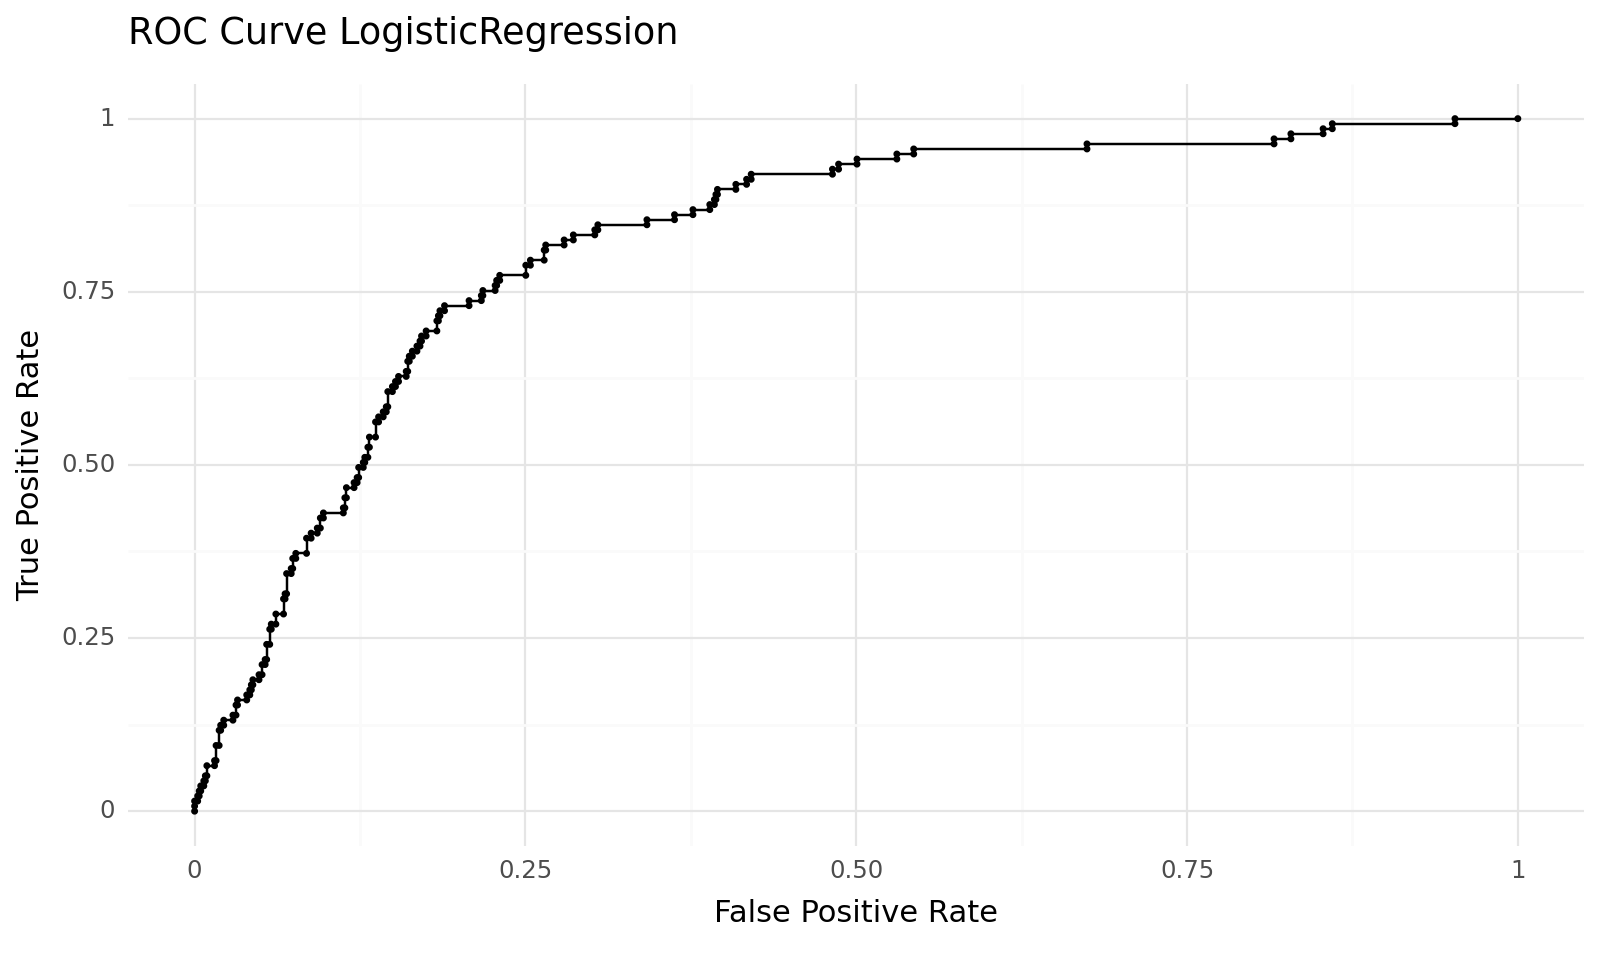

<Figure Size: (800 x 480)>

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
# Рисуем ROC кривую
df_fpr_tpr = pd.DataFrame({'FPR':fpr, 'TPR':tpr, 'Threshold':thresholds})
df_fpr_tpr.head()

plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_fpr_tpr)+
    geom_point(aes(x = 'FPR',
                   y = 'TPR'),
               size = 0.4)+
    geom_line(aes(x = 'FPR',
                  y = 'TPR'))+
    labs(title = 'ROC Curve LogisticRegression')+
    xlab('False Positive Rate')+
    ylab('True Positive Rate')+
    theme_minimal()
)

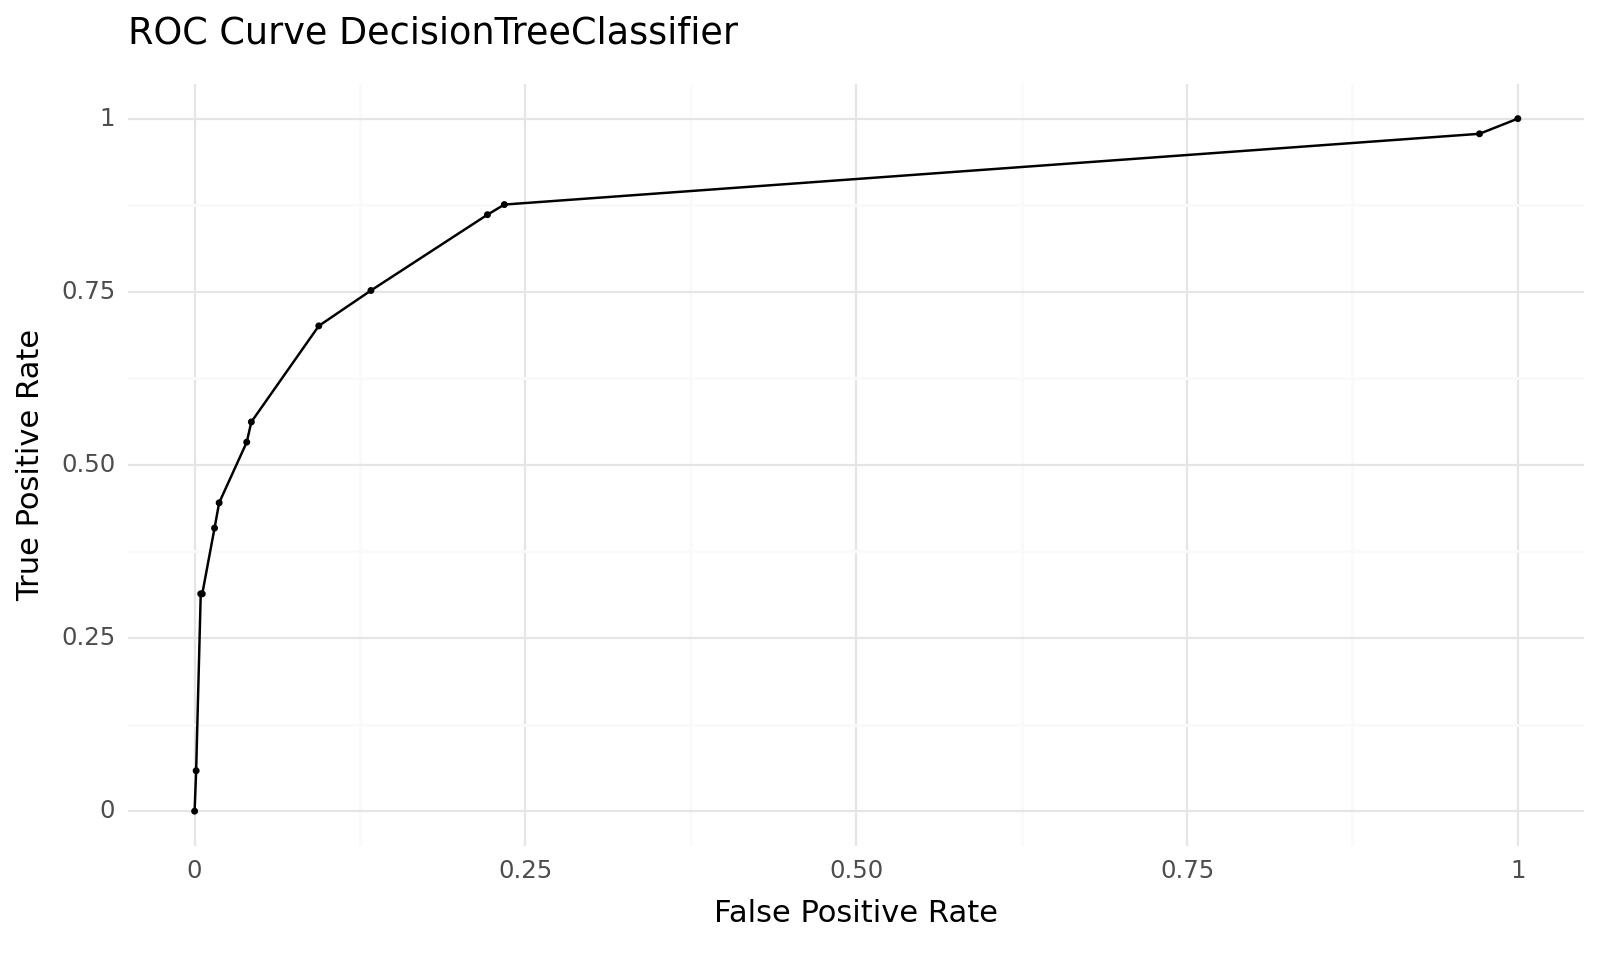

<Figure Size: (800 x 480)>

In [34]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_DT)
# Рисуем ROC кривую
df_fpr_tpr = pd.DataFrame({'FPR':fpr, 'TPR':tpr, 'Threshold':thresholds})
df_fpr_tpr.head()

plotnine.options.figure_size = (8, 4.8)
(
    ggplot(data = df_fpr_tpr)+
    geom_point(aes(x = 'FPR',
                   y = 'TPR'),
               size = 0.4)+
    geom_line(aes(x = 'FPR',
                  y = 'TPR'))+
    labs(title = 'ROC Curve DecisionTreeClassifier')+
    xlab('False Positive Rate')+
    ylab('True Positive Rate')+
    theme_minimal()
)

Сравните между собой две лучшие модели:

1. Насколько сильно отличается качество предсказания на тестовых данных?
(Вычислите разность значений roc-auc.)

2. Постройте гистограммы важности признаков (для линейных моделей берите модуль значений весов) для каждой из этих моделей. Сравните между собой списки из трёх самых важных признаков. Совпадают ли они?

In [35]:
# ваш код здесь

In [36]:
#результат для Logistic Regression: 0.8153681602729712
#результат для DecisionTree: 0.8742701670080983
#разность значений roc-auc 0.05890200673512713

In [37]:
0.8153681602729712-0.8742701670080983

-0.05890200673512713

In [38]:
# ваш код здесь

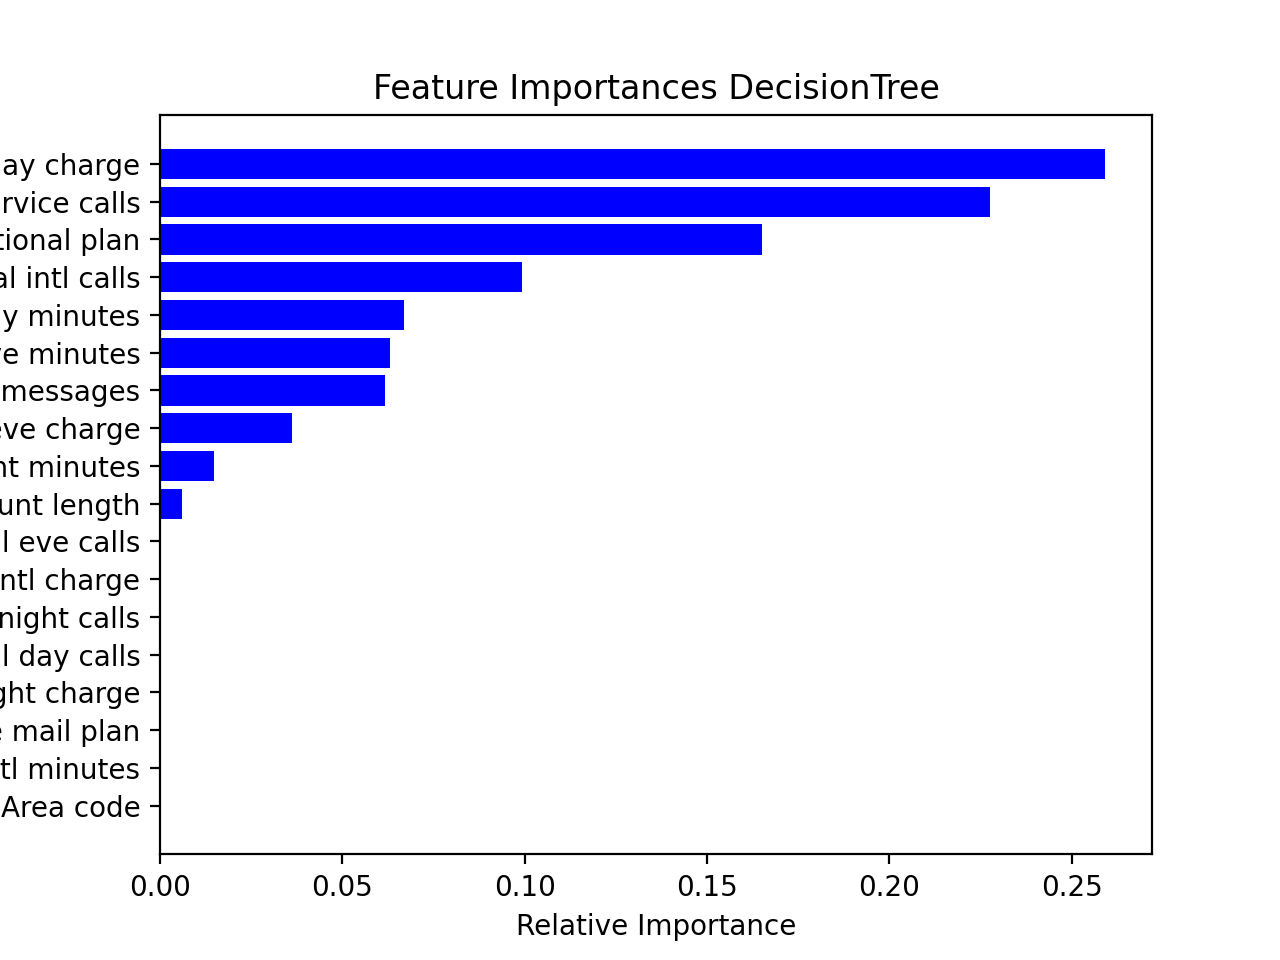

In [39]:
features = X.columns
importances = model_DT.feature_importances_
indices = np.argsort(importances)

plt.title('Feature Importances DecisionTree')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


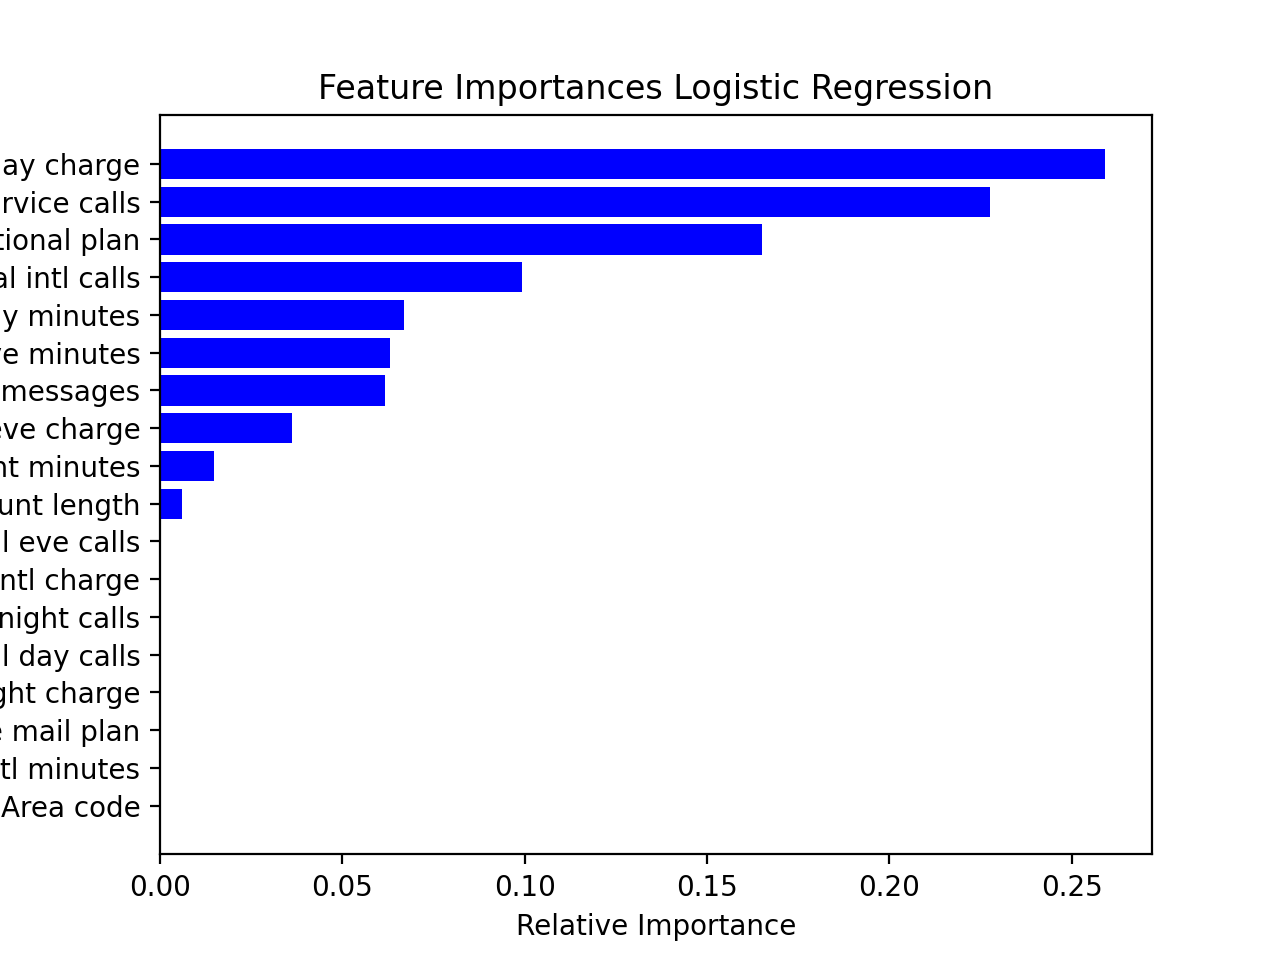

In [40]:
importance = np.abs(model_logreg.coef_[0])
indices = np.argsort(importances)

plt.title('Feature Importances Logistic Regression')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

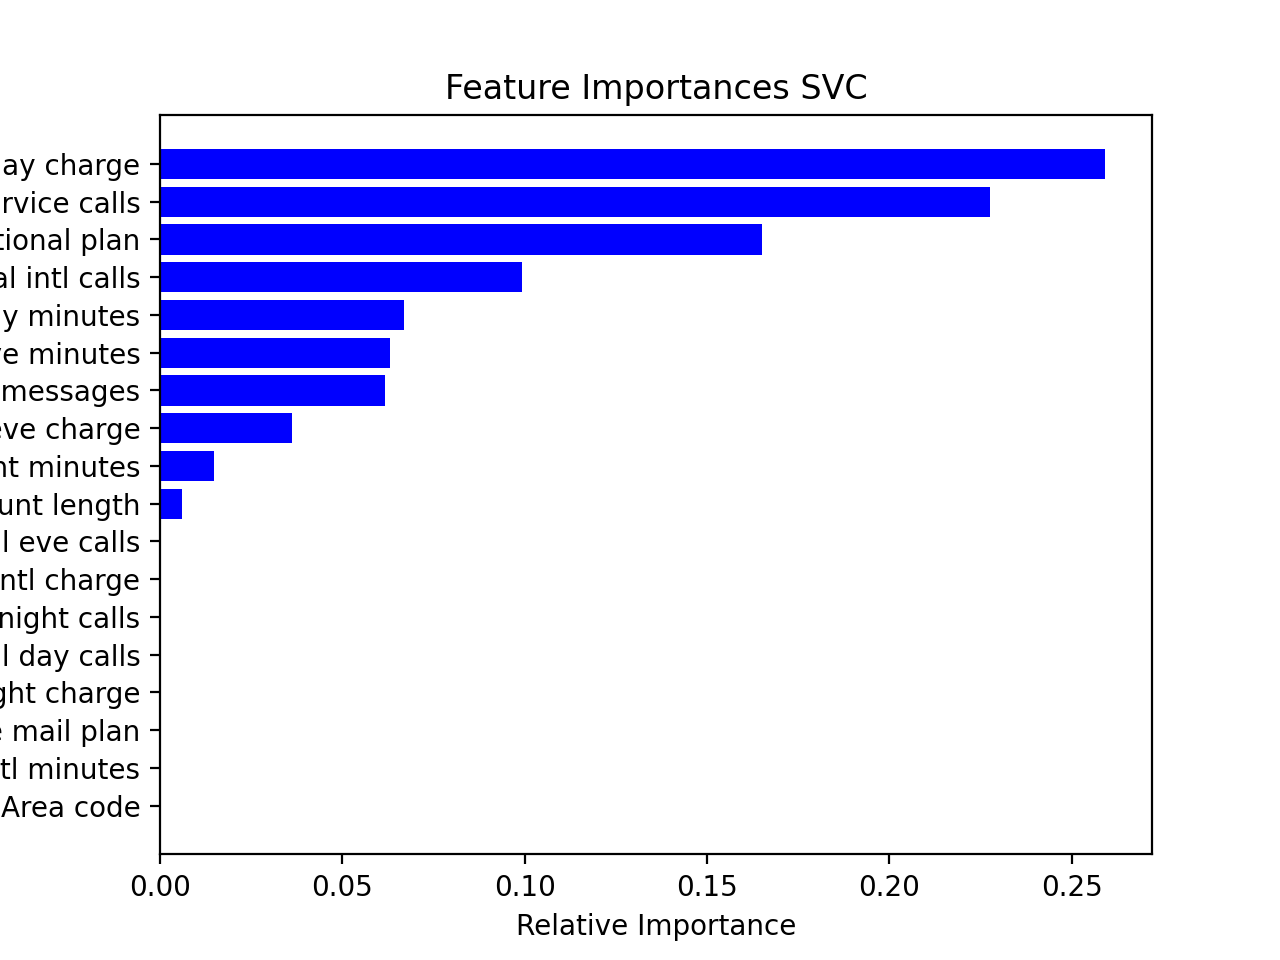

In [41]:
importance = np.abs(model_SVC.coef_[0])
indices = np.argsort(importances)

plt.title('Feature Importances SVC')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Сделайте выводы:

1. Являются ли данные сбалансированными? Что это означает?

2. Какая модель после подбора гиперпараметров лучше всего решает задачу с точки зрения метрики roc-auc?

3. Одинаковые ли признаки важны для работы двух наилучших моделей? Почему?

Данные не являются сбалансированными. Это означает, что в данных имеется значительное преобладание одного класса над 
другим. Такая ситуация может привести к тому, что модель будет плохо обобщать неизвестные данные, так как она может 
просто “научиться” всегда предсказывать один класс.
После подбора гиперпараметров лучше всего решает задачу DecisionTree, с точки зрения метрики roc-auc
Признаки, которые важны для каждой модели, могут быть разными. Это связано с тем, что каждый метод оптимизации 
может уделять больше внимания определенным признакам, в зависимости от того, как они влияют на целевую функцию. 